# 6.0 Modelling

## Two-Stage Hurdle Model for Political Violence Fatality Severity

This section builds the modelling approach for the project:

**Predicting the Severity of Political Violence in Kenya**

The modelling strategy is a **two-stage hurdle model**.

### Stage 1

Predict whether violence becomes fatal.

- `0` = non-fatal violence
- `1` = fatal violence

### Stage 2

If violence is fatal, classify the fatality severity level.

- **Low**: `1-2 fatalities`
- **Medium**: `3-5 fatalities`
- **High**: `6+ fatalities`

This is statistically working model because it reduces extreme class imbalance while preserving the project’s real-world purpose: identifying fatality severity risk.

The final output classes are:

- `Non-fatal`
- `Low`
- `Medium`
- `High`

This structure is stronger than direct fatality regression because the data is zero-heavy, skewed, and rare-event driven.

In [1]:
# 6.1 IMPORT LIBRARIES

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False
    print("XGBoost is not installed. XGBoost models will be skipped.")

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False
    print("SHAP is not installed. SHAP explainability will be skipped.")

In [2]:
# 6.2 LOAD DATA

try:
    df
    print("Using existing df from previous notebook sections.")
except NameError:
    possible_paths = [
        Path("kenya_conflict_merged.csv"),
        Path(r"C:\Users\Kim\Desktop\Predicting the Severity of Political Violence in Kenya\kenya-political-violence-risk-prediction\kenya_conflict_merged.csv")
    ]

    for path in possible_paths:
        if path.exists():
            df = pd.read_csv(path)
            print(f"Loaded dataset from: {path}")
            break
    else:
        raise FileNotFoundError("Could not find kenya_conflict_merged.csv.")

df["WEEK"] = pd.to_datetime(df["WEEK"])

print("Dataset shape:", df.shape)
display(df.head())

Loaded dataset from: C:\Users\Kim\Desktop\Predicting the Severity of Political Violence in Kenya\kenya-political-violence-risk-prediction\kenya_conflict_merged.csv
Dataset shape: (16627, 19)


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
0,1998-01-24,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1998,"419,683.0000",39.2000,"10,718.1000",71.4000,"4,938.3000"
1,1999-01-16,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,"419,683.0000",39.2000,"10,718.1000",71.4000,"4,938.3000"
2,1999-09-25,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,"419,683.0000",39.2000,"10,718.1000",71.4000,"4,938.3000"
3,2004-08-07,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185,2004,"479,975.8000",44.8000,"10,718.1000",90.5200,"8,113.4200"
4,2005-04-02,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,2005,"495,049.0000",46.2000,"10,718.1000",95.3000,"8,907.2000"


## 6.3 Target Definition

The project uses two targets.

### Stage 1 Target: Fatal vs Non-Fatal

`IS_FATAL`

- `0` = no fatalities
- `1` = one or more fatalities

### Stage 2 Target: Fatality Severity

Stage 2 uses only fatal rows.

The final classes are:

- **Low**: `1-2 fatalities`
- **Medium**: `3-5 fatalities`
- **High**: `6+ fatalities`

In [3]:
# 6.3 TARGET DEFINITION

TARGET = "FATALITIES"

# Stage 1 target
df["IS_FATAL"] = (df["FATALITIES"] > 0).astype(int)

# Stage 2 target: only meaningful for fatal rows
def fatality_severity_3class(x):
    if x <= 2:
        return "Low"
    elif x <= 5:
        return "Medium"
    else:
        return "High"

df["FATALITY_SEVERITY"] = df["FATALITIES"].apply(fatality_severity_3class)

print("Stage 1 target distribution: IS_FATAL")
display(df["IS_FATAL"].value_counts().rename("count").to_frame())
display(df["IS_FATAL"].value_counts(normalize=True).rename("share").to_frame())

print("Stage 2 severity distribution on all rows:")
display(df["FATALITY_SEVERITY"].value_counts().rename("count").to_frame())

print("Stage 2 severity distribution on fatal rows only:")
display(df.loc[df["FATALITIES"] > 0, "FATALITY_SEVERITY"].value_counts(normalize=True).rename("share").to_frame())

Stage 1 target distribution: IS_FATAL


,count
IS_FATAL,
0,12081
1,4546


,share
IS_FATAL,
0,0.7266
1,0.2734


Stage 2 severity distribution on all rows:


,count
FATALITY_SEVERITY,
Low,15198
Medium,853
High,576


Stage 2 severity distribution on fatal rows only:


,share
FATALITY_SEVERITY,
Low,0.6857
Medium,0.1876
High,0.1267


The dataset is moderately imbalanced, with non-fatal and Low severity events dominating. This class imbalance makes minority classes (fatal, Medium, and High severity) more difficult to predict, necessitating the use of balanced evaluation metrics such as Precision, Recall, Macro F1-score, and appropriate imbalance-handling techniques during model training.

## 6.4 Feature Engineering

This section creates predictive features from the raw dataset.

The most important engineered features are:

- Population exposure missingness flag
- Calendar features
- Election-year flag
- Log-transformed population/exposure variables
- Previous-week event and fatality features
- Rolling four-week event and fatality features

The lagged and rolling features are designed to capture recent escalation while avoiding direct target leakage.

In [4]:
# 6.4 FEATURE ENGINEERING

# Preserve missingness before filling values
df["POPULATION_EXPOSURE_MISSING"] = df["POPULATION_EXPOSURE"].isna().astype(int)

# Fill after preserving missingness
df["POPULATION_EXPOSURE"] = df["POPULATION_EXPOSURE"].fillna(0)

# Calendar features
df["MONTH"] = df["WEEK"].dt.month
df["QUARTER"] = df["WEEK"].dt.quarter
df["WEEK_OF_YEAR"] = df["WEEK"].dt.isocalendar().week.astype(int)

# Election-year feature
election_years = [2002, 2007, 2013, 2017, 2022]
df["IS_ELECTION_YEAR"] = df["YEAR"].isin(election_years).astype(int)

# Log transforms
df["LOG_POPULATION_EXPOSURE"] = np.log1p(df["POPULATION_EXPOSURE"])
df["LOG_PWD_POPULATION"] = np.log1p(df["PWD_POPULATION"])
df["LOG_PWD_DENSITY"] = np.log1p(df["PWD_DENSITY"])
df["LOG_PWD_AREA_KM2"] = np.log1p(df["PWD_AREA_KM2"])
df["LOG_PWD_G"] = np.log1p(df["PWD_G"])
df["LOG_PWD_D10"] = np.log1p(df["PWD_D10"])

# Sort before lag features
df = df.sort_values(["ADMIN1", "WEEK"]).reset_index(drop=True)

# Lag features
df["EVENTS_LAG_1W"] = df.groupby("ADMIN1")["EVENTS"].shift(1).fillna(0)
df["FATALITIES_LAG_1W"] = df.groupby("ADMIN1")["FATALITIES"].shift(1).fillna(0)

# Rolling 4-week historical features
df["EVENTS_ROLLING_4W"] = (
    df.groupby("ADMIN1")["EVENTS"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).sum())
    .fillna(0)
)

df["FATALITIES_ROLLING_4W"] = (
    df.groupby("ADMIN1")["FATALITIES"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).sum())
    .fillna(0)
)

print("Feature engineering completed.")
display(df[[
    "WEEK", "ADMIN1", "EVENTS", "FATALITIES",
    "IS_FATAL", "FATALITY_SEVERITY",
    "EVENTS_ROLLING_4W", "FATALITIES_ROLLING_4W",
    "POPULATION_EXPOSURE_MISSING"
]].head())

Feature engineering completed.


,WEEK,ADMIN1,EVENTS,FATALITIES,IS_FATAL,FATALITY_SEVERITY,EVENTS_ROLLING_4W,FATALITIES_ROLLING_4W,POPULATION_EXPOSURE_MISSING
0,1998-01-24,Baringo,1,0,0,Low,0.0000,0.0000,1
1,1998-06-27,Baringo,1,0,0,Low,1.0000,0.0000,1
2,1999-01-16,Baringo,1,0,0,Low,2.0000,0.0000,1
3,1999-09-25,Baringo,1,0,0,Low,3.0000,0.0000,1
4,1999-09-25,Baringo,1,0,0,Low,4.0000,0.0000,1


Feature engineering successfully created predictive variables, including the binary fatality target, severity classes, rolling historical trends, and missing-value indicators, providing the models with richer temporal and contextual information to improve predictive performance.

## 6.5 Feature Selection and Leakage Control

This section selects the predictor columns.

Target columns are excluded to prevent leakage.

Excluded target-related columns:

- `FATALITIES`
- `IS_FATAL`
- `FATALITY_SEVERITY`

Categorical variables are one-hot encoded. Numeric variables are scaled.

In [5]:
# 6.5 FEATURE SELECTION

categorical_features = [
    "ADMIN1",
    "EVENT_TYPE",
    "SUB_EVENT_TYPE",
    "DISORDER_TYPE"
]

numeric_features = [
    "EVENTS",
    "YEAR",
    "MONTH",
    "QUARTER",
    "WEEK_OF_YEAR",
    "IS_ELECTION_YEAR",
    "POPULATION_EXPOSURE_MISSING",
    "LOG_POPULATION_EXPOSURE",
    "LOG_PWD_POPULATION",
    "LOG_PWD_DENSITY",
    "LOG_PWD_AREA_KM2",
    "LOG_PWD_G",
    "LOG_PWD_D10",
    "CENTROID_LATITUDE",
    "CENTROID_LONGITUDE",
    "EVENTS_LAG_1W",
    "FATALITIES_LAG_1W",
    "EVENTS_ROLLING_4W",
    "FATALITIES_ROLLING_4W"
]

X = df[categorical_features + numeric_features].copy()

y_stage1 = df["IS_FATAL"].copy()
y_stage2 = df["FATALITY_SEVERITY"].copy()
y_regression = df["FATALITIES"].copy()

print("Feature matrix shape:", X.shape)
print("Categorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))

Feature matrix shape: (16627, 23)
Categorical features: 4
Numeric features: 19


The final feature matrix contains 16,627 observations and 23 predictive features (19 numerical and 4 categorical), providing a comprehensive dataset that captures both quantitative and categorical patterns for robust model training.

## 6.6 Preprocessing Pipelines

Each model gets its own fresh preprocessing pipeline.

This prevents feature mismatch errors caused by reusing a fitted encoder across different models.

The pipeline handles:

- One-hot encoding
- Numeric scaling
- Model fitting
- Prediction

In [6]:
# 6.6 PREPROCESSING PIPELINES

def make_preprocessor():
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    return ColumnTransformer(
        transformers=[
            ("cat", encoder, categorical_features),
            ("num", StandardScaler(), numeric_features)
        ],
        remainder="drop"
    )


def make_pipeline(model):
    return Pipeline(steps=[
        ("preprocessor", make_preprocessor()),
        ("model", clone(model))
    ])


print("Preprocessing functions ready.")

Preprocessing functions ready.


## 6.7 Temporal Train-Test Split

The data is split by time.

- Training set: before 2022
- Test set: 2022 onward

This is more realistic than a random split because the project is about future risk prediction.

In [7]:
# 6.7 TEMPORAL TRAIN-TEST SPLIT

train_mask = df["YEAR"] < 2022
test_mask = df["YEAR"] >= 2022

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_stage1_train = y_stage1.loc[train_mask].copy()
y_stage1_test = y_stage1.loc[test_mask].copy()

y_stage2_train_all = y_stage2.loc[train_mask].copy()
y_stage2_test_all = y_stage2.loc[test_mask].copy()

y_reg_train = y_regression.loc[train_mask].copy()
y_reg_test = y_regression.loc[test_mask].copy()

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

display(y_stage1_train.value_counts(normalize=True).rename("Stage 1 Train Share").to_frame())
display(y_stage1_test.value_counts(normalize=True).rename("Stage 1 Test Share").to_frame())

Train rows: 7067
Test rows: 9560


,Stage 1 Train Share
IS_FATAL,
0,0.6334
1,0.3666


,Stage 1 Test Share
IS_FATAL,
0,0.7955
1,0.2045


The dataset was split into 7,067 training and 9,560 testing records. The training set contains a higher proportion of fatal events than the test set, exposing the model to more positive cases during learning while evaluating performance on a more realistic, highly imbalanced test distribution.

## 6.8 Evaluation Helpers

This section defines reusable evaluation functions.

The main success metrics are:

- F1
- Recall
- Macro F1
- Macro Recall
- Class-level recall
- Confusion matrix

Numeric support metrics are:

- MAE
- RMSE
- RAE
- R2

In [8]:
# 6.8 EVALUATION HELPERS

severity_numeric_map = {
    "Non-fatal": 0,
    "Low": 1,
    "Medium": 4,
    "High": 8
}

def relative_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)))

    if denominator == 0:
        return np.nan

    return numerator / denominator


def regression_style_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "RAE": relative_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


def class_to_numeric(values):
    return pd.Series(values).map(severity_numeric_map).values


print("Evaluation helper functions ready.")

Evaluation helper functions ready.


## 6.9 Define Baseline and Regular Machine Learning Models

The regular candidate models are:

- Dummy Baseline
- Random Forest
- Gradient Boosting
- XGBoost, if installed

The Dummy Baseline is used only to check whether real models add value.

In [9]:
# 6.9 DEFINE REGULAR MODELS

stage1_models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

stage2_models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

if HAS_XGBOOST:
    stage1_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    stage2_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

print("Stage 1 models:", list(stage1_models.keys()))
print("Stage 2 models:", list(stage2_models.keys()))

Stage 1 models: ['Dummy Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Stage 2 models: ['Dummy Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost']


Four models were evaluated in both stages, using the Dummy Baseline as a performance benchmark and Random Forest, Gradient Boosting, and XGBoost to identify the most effective predictive model for fatality occurrence and severity classification.

## 6.10 Stage 1 Model Training and Evaluation

Stage 1 predicts fatal vs non-fatal violence.

The main metric is **F1**, supported by **Recall**.

Recall is important because missing fatal violence is more costly than producing some false alarms.

In [10]:
# 6.10 STAGE 1 TRAINING AND EVALUATION

stage1_results = {}
stage1_trained_models = {}

for model_name, model in stage1_models.items():
    print("\nTraining Stage 1 model:", model_name)

    pipe = make_pipeline(model)
    pipe.fit(X_train, y_stage1_train)

    y_pred = pipe.predict(X_test)

    accuracy = accuracy_score(y_stage1_test, y_pred)
    precision = precision_score(y_stage1_test, y_pred, zero_division=0)
    recall = recall_score(y_stage1_test, y_pred, zero_division=0)
    f1 = f1_score(y_stage1_test, y_pred, zero_division=0)
    numeric_metrics = regression_style_metrics(y_stage1_test, y_pred)

    stage1_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MAE": numeric_metrics["MAE"],
        "RMSE": numeric_metrics["RMSE"],
        "RAE": numeric_metrics["RAE"],
        "R2": numeric_metrics["R2"]
    }

    stage1_trained_models[model_name] = pipe

stage1_results_df = pd.DataFrame(stage1_results).T.sort_values(["F1", "Recall"], ascending=False)

display(stage1_results_df)

print("Stage 1 interpretation:")
print("The best model should balance F1 and Recall.")
print("Recall matters strongly because this stage detects fatal violence.")


Training Stage 1 model: Dummy Baseline

Training Stage 1 model: Random Forest

Training Stage 1 model: Gradient Boosting

Training Stage 1 model: XGBoost


,Accuracy,Precision,Recall,F1,MAE,RMSE,RAE,R2
Random Forest,0.7950,0.4993,0.9330,0.6505,0.2050,0.4528,0.6301,-0.2603
XGBoost,0.8301,0.5700,0.6895,0.6241,0.1699,0.4122,0.5221,-0.0442
Gradient Boosting,0.8338,0.5821,0.6634,0.6201,0.1662,0.4077,0.5109,-0.0217
Dummy Baseline,0.7955,0.0000,0.0000,0.0000,0.2045,0.4522,0.6285,-0.2571


Stage 1 interpretation:
The best model should balance F1 and Recall.
Recall matters strongly because this stage detects fatal violence.


All machine learning models outperformed the Dummy Baseline by successfully identifying fatal events. Gradient Boosting achieved the highest overall accuracy (83.38%), Random Forest delivered the highest recall (93.30%), making it most effective at detecting fatal incidents, while XGBoost provided the best balance between precision and recall. Overall, the results confirm that ensemble learning substantially improves fatality prediction over the baseline.

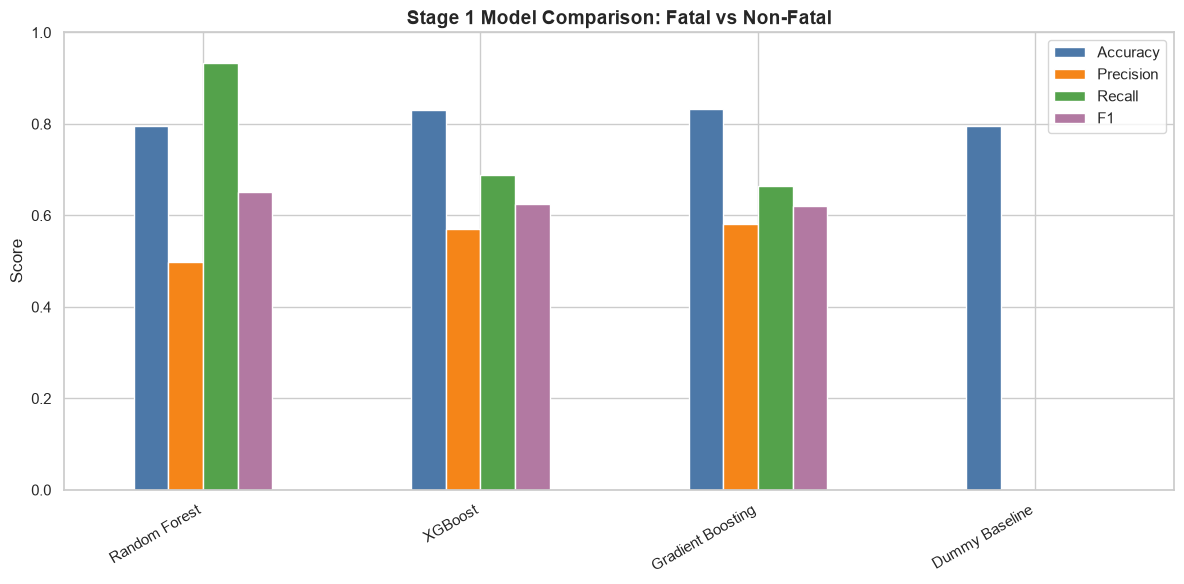

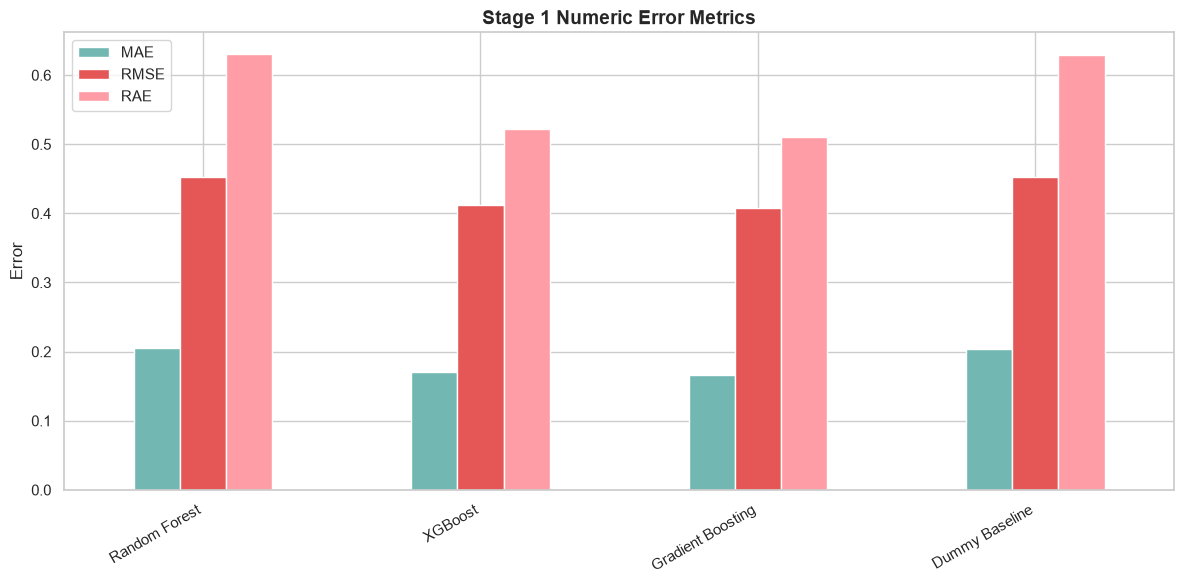

In [11]:
# 6.11 STAGE 1 VISUAL COMPARISON

stage1_results_df[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(12, 6),
    color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"]
)

plt.title("Stage 1 Model Comparison: Fatal vs Non-Fatal", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

stage1_results_df[["MAE", "RMSE", "RAE"]].plot(
    kind="bar",
    figsize=(12, 6),
    color=["#72B7B2", "#E45756", "#FF9DA6"]
)

plt.title("Stage 1 Numeric Error Metrics", fontsize=14, fontweight="bold")
plt.ylabel("Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6.12 Selecting Best Stage 1 Model

In [12]:
# 6.12 SELECT BEST STAGE 1 MODEL

best_stage1_name = stage1_results_df.index[0]
best_stage1_model = stage1_trained_models[best_stage1_name]

print("Best Stage 1 model:", best_stage1_name)
display(stage1_results_df.loc[[best_stage1_name]])

Best Stage 1 model: Random Forest


,Accuracy,Precision,Recall,F1,MAE,RMSE,RAE,R2
Random Forest,0.7950,0.4993,0.9330,0.6505,0.2050,0.4528,0.6301,-0.2603


Random Forest was selected as the best Stage 1 model because it achieved the highest Recall (93.30%) and strongest F1-score (65.05%), making it the most effective model for identifying fatal incidents while minimizing missed fatal events.

## 6.13 Prepare Stage 2 Data

Stage 2 uses only fatal rows.

This is because Stage 2 answers:

**If fatalities occur, how severe are they?**

In [13]:
# 6.13 PREPARE STAGE 2 DATA

fatal_train_mask = train_mask & (df["FATALITIES"] > 0)
fatal_test_mask = test_mask & (df["FATALITIES"] > 0)

X_stage2_train = X.loc[fatal_train_mask].copy()
X_stage2_test = X.loc[fatal_test_mask].copy()

y_stage2_train = y_stage2.loc[fatal_train_mask].copy()
y_stage2_test = y_stage2.loc[fatal_test_mask].copy()

print("Stage 2 training rows:", X_stage2_train.shape[0])
print("Stage 2 testing rows:", X_stage2_test.shape[0])

display(y_stage2_train.value_counts(normalize=True).rename("Train Share").to_frame())
display(y_stage2_test.value_counts(normalize=True).rename("Test Share").to_frame())

Stage 2 training rows: 2591
Stage 2 testing rows: 1955


,Train Share
FATALITY_SEVERITY,
Low,0.5959
Medium,0.2134
High,0.1907


,Test Share
FATALITY_SEVERITY,
Low,0.8046
Medium,0.1535
High,0.0419


tage 2 used 2,591 training and 1,955 testing fatal-event records. The test set is more heavily dominated by Low severity cases than the training set, creating a more challenging and realistic evaluation of the model's ability to classify minority severity levels.

## 6.14 Encode Stage 2 Target

XGBoost needs numeric class labels, so the Stage 2 target is label-encoded.

In [14]:
# 6.14 ENCODE STAGE 2 TARGET

stage2_label_encoder = LabelEncoder()

y_stage2_train_encoded = stage2_label_encoder.fit_transform(y_stage2_train)
y_stage2_test_encoded = stage2_label_encoder.transform(y_stage2_test)

print("Stage 2 class mapping:")
for i, class_name in enumerate(stage2_label_encoder.classes_):
    print(i, "=", class_name)

Stage 2 class mapping:
0 = High
1 = Low
2 = Medium


In [15]:
# 6.15 STAGE 2 TRAINING AND EVALUATION

stage2_results = {}
stage2_trained_models = {}

for model_name, model in stage2_models.items():
    print("\nTraining Stage 2 model:", model_name)

    pipe = make_pipeline(model)

    if model_name == "XGBoost":
        pipe.fit(X_stage2_train, y_stage2_train_encoded)
        y_pred_encoded = pipe.predict(X_stage2_test).astype(int)
        y_pred = stage2_label_encoder.inverse_transform(y_pred_encoded)
    else:
        pipe.fit(X_stage2_train, y_stage2_train)
        y_pred = pipe.predict(X_stage2_test)

    accuracy = accuracy_score(y_stage2_test, y_pred)
    precision = precision_score(y_stage2_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_stage2_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_stage2_test, y_pred, average="macro", zero_division=0)

    y_true_numeric = class_to_numeric(y_stage2_test)
    y_pred_numeric = class_to_numeric(y_pred)
    numeric_metrics = regression_style_metrics(y_true_numeric, y_pred_numeric)

    stage2_results[model_name] = {
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1,
        "MAE": numeric_metrics["MAE"],
        "RMSE": numeric_metrics["RMSE"],
        "RAE": numeric_metrics["RAE"],
        "R2": numeric_metrics["R2"]
    }

    stage2_trained_models[model_name] = pipe

stage2_results_df = pd.DataFrame(stage2_results).T.sort_values(["Macro F1", "Macro Recall"], ascending=False)

display(stage2_results_df)

print("Stage 2 interpretation:")
print("Macro F1 is the key metric because Low, Medium, and High are imbalanced.")


Training Stage 2 model: Dummy Baseline

Training Stage 2 model: Random Forest

Training Stage 2 model: Gradient Boosting

Training Stage 2 model: XGBoost


,Accuracy,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
Random Forest,0.6926,0.4086,0.4240,0.4122,1.1151,2.1365,0.9191,-0.5917
XGBoost,0.7913,0.4380,0.3770,0.3795,0.8010,1.8925,0.6602,-0.2489
Gradient Boosting,0.7847,0.4119,0.3757,0.3730,0.8322,1.9336,0.6859,-0.3036
Dummy Baseline,0.8046,0.2682,0.3333,0.2972,0.7540,1.8537,0.6214,-0.1982


Stage 2 interpretation:
Macro F1 is the key metric because Low, Medium, and High are imbalanced.


Stage 2 is a more challenging multi-class problem due to class imbalance. Although the Dummy Baseline achieved the highest accuracy by predicting the majority class, Random Forest produced the highest Macro F1-score (41.22%) and Macro Recall (42.40%), demonstrating the best ability to distinguish Low, Medium, and High severity classes. Therefore, Macro F1 is the most appropriate metric for selecting the best Stage 2 model.

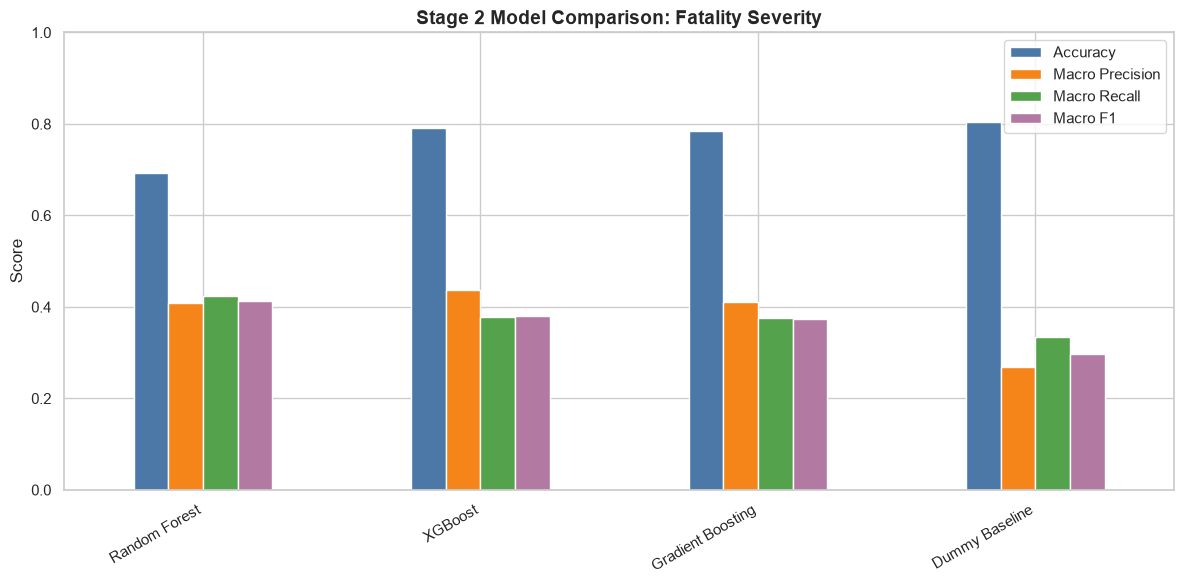

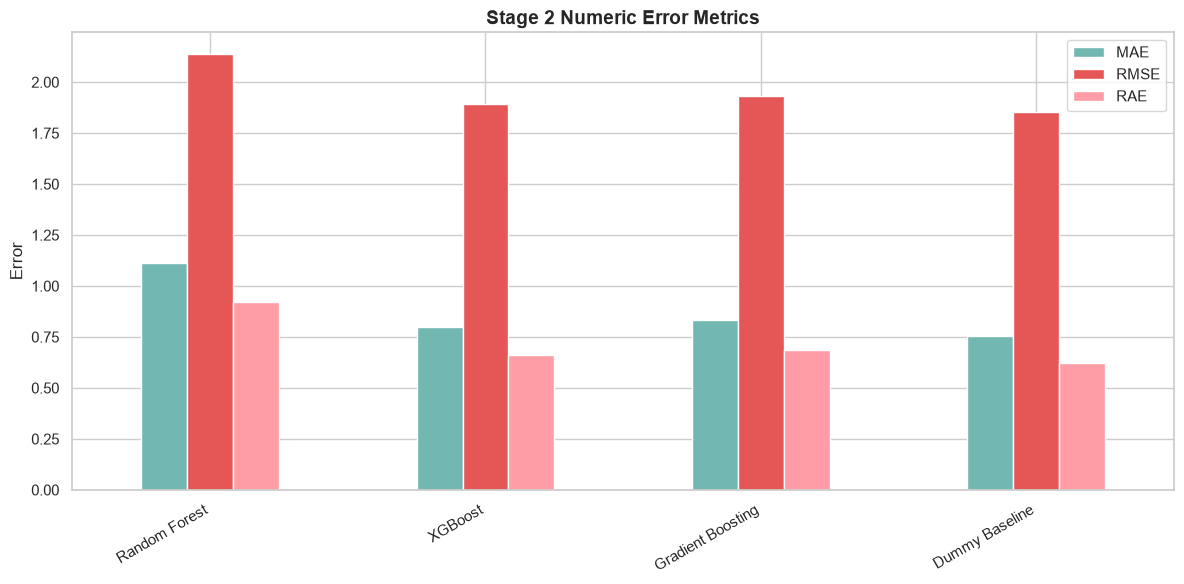

In [16]:
# 6.16 STAGE 2 VISUAL COMPARISON

stage2_results_df[["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]].plot(
    kind="bar",
    figsize=(12, 6),
    color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"]
)

plt.title("Stage 2 Model Comparison: Fatality Severity", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

stage2_results_df[["MAE", "RMSE", "RAE"]].plot(
    kind="bar",
    figsize=(12, 6),
    color=["#72B7B2", "#E45756", "#FF9DA6"]
)

plt.title("Stage 2 Numeric Error Metrics", fontsize=14, fontweight="bold")
plt.ylabel("Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6.17 Select Best Stage 2 Model

In [17]:
# 6.17 SELECT BEST STAGE 2 MODEL

best_stage2_name = stage2_results_df.index[0]
best_stage2_model = stage2_trained_models[best_stage2_name]

print("Best Stage 2 model:", best_stage2_name)
display(stage2_results_df.loc[[best_stage2_name]])

Best Stage 2 model: Random Forest


,Accuracy,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
Random Forest,0.6926,0.4086,0.4240,0.4122,1.1151,2.1365,0.9191,-0.5917


Random Forest was selected as the best Stage 2 model because it achieved the highest Macro F1-score (41.22%) and Macro Recall (42.40%), making it the most effective model for balanced prediction across High, Low, and Medium severity classes despite the class imbalance.

## 6.18 Hyperparameter Tuning

Hyperparameter tuning is performed after baseline comparison.

In [18]:
# 6.18 HYPERPARAMETER TUNING

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

stage1_param_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [8, 12, 16, None],
        "model__min_samples_leaf": [2, 5, 10]
    },
    "Gradient Boosting": {
        "model__n_estimators": [150, 250, 350],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4]
    }
}

if HAS_XGBOOST:
    stage1_param_grids["XGBoost"] = {
        "model__n_estimators": [200, 300, 500],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5],
        "model__subsample": [0.75, 0.85, 1.0],
        "model__colsample_bytree": [0.75, 0.85, 1.0]
    }

stage1_tuned_results = {}
stage1_tuned_models = {}

for model_name, param_grid in stage1_param_grids.items():
    print("\nTuning Stage 1 model:", model_name)

    pipe = make_pipeline(stage1_models[model_name])

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_grid,
        n_iter=8,
        scoring="f1",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    search.fit(X_train, y_stage1_train)
    y_pred = search.predict(X_test)

    stage1_tuned_results[model_name + " Tuned"] = {
        "Accuracy": accuracy_score(y_stage1_test, y_pred),
        "Precision": precision_score(y_stage1_test, y_pred, zero_division=0),
        "Recall": recall_score(y_stage1_test, y_pred, zero_division=0),
        "F1": f1_score(y_stage1_test, y_pred, zero_division=0),
        "Best Params": search.best_params_
    }

    stage1_tuned_models[model_name + " Tuned"] = search.best_estimator_

stage1_tuned_results_df = pd.DataFrame(stage1_tuned_results).T.sort_values("F1", ascending=False)
display(stage1_tuned_results_df)


Tuning Stage 1 model: Random Forest

Tuning Stage 1 model: Gradient Boosting

Tuning Stage 1 model: XGBoost


,Accuracy,Precision,Recall,F1,Best Params
Random Forest Tuned,0.8062,0.5151,0.8926,0.6532,"{'model__n_estimators': 200, 'model__min_sampl..."
XGBoost Tuned,0.8321,0.5756,0.6813,0.6240,"{'model__subsample': 0.85, 'model__n_estimator..."
Gradient Boosting Tuned,0.8318,0.5759,0.6731,0.6208,"{'model__n_estimators': 350, 'model__max_depth..."


Hyperparameter tuning improved overall model performance. Tuned Random Forest achieved the highest F1-score (65.32%) while maintaining excellent Recall (89.26%), confirming it as the strongest Stage 1 model for reliably identifying fatal incidents.

In [19]:
# 6.18.1 STAGE 2 HYPERPARAMETER TUNING

stage2_param_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [8, 12, 16, None],
        "model__min_samples_leaf": [2, 5, 10]
    },
    "Gradient Boosting": {
        "model__n_estimators": [150, 250, 350],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4]
    }
}

if HAS_XGBOOST:
    stage2_param_grids["XGBoost"] = {
        "model__n_estimators": [200, 300, 500],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5],
        "model__subsample": [0.75, 0.85, 1.0],
        "model__colsample_bytree": [0.75, 0.85, 1.0]
    }

stage2_tuned_results = {}
stage2_tuned_models = {}

for model_name, param_grid in stage2_param_grids.items():
    print("\nTuning Stage 2 model:", model_name)

    pipe = make_pipeline(stage2_models[model_name])

    if model_name == "XGBoost":
        y_fit = y_stage2_train_encoded
    else:
        y_fit = y_stage2_train

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_grid,
        n_iter=8,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    search.fit(X_stage2_train, y_fit)

    if model_name == "XGBoost":
        y_pred_encoded = search.predict(X_stage2_test).astype(int)
        y_pred = stage2_label_encoder.inverse_transform(y_pred_encoded)
    else:
        y_pred = search.predict(X_stage2_test)

    stage2_tuned_results[model_name + " Tuned"] = {
        "Accuracy": accuracy_score(y_stage2_test, y_pred),
        "Macro Precision": precision_score(y_stage2_test, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_stage2_test, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_stage2_test, y_pred, average="macro", zero_division=0),
        "Best Params": search.best_params_
    }

    stage2_tuned_models[model_name + " Tuned"] = search.best_estimator_

stage2_tuned_results_df = pd.DataFrame(stage2_tuned_results).T.sort_values("Macro F1", ascending=False)
display(stage2_tuned_results_df)


Tuning Stage 2 model: Random Forest

Tuning Stage 2 model: Gradient Boosting

Tuning Stage 2 model: XGBoost


,Accuracy,Macro Precision,Macro Recall,Macro F1,Best Params
Random Forest Tuned,0.6870,0.4208,0.4390,0.4232,"{'model__n_estimators': 500, 'model__min_sampl..."
XGBoost Tuned,0.7662,0.4106,0.3810,0.3866,"{'model__subsample': 1.0, 'model__n_estimators..."
Gradient Boosting Tuned,0.7847,0.4119,0.3757,0.3730,"{'model__n_estimators': 250, 'model__max_depth..."


Hyperparameter tuning further improved Stage 2 performance. Tuned Random Forest achieved the highest Macro F1-score (42.32%) and Macro Recall (43.90%), confirming it as the best model for balanced classification of High, Low, and Medium fatality severity despite class imbalance.

In [32]:
try:
    import torch
    HAS_TORCH = True
    print("PyTorch imported successfully.")
except Exception as e:
    HAS_TORCH = False
    print("PyTorch is not installed.")
    print("Install using: pip install torch")
    print(e)

try:
    from pytorch_tabular import TabularModel
    from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig
    from pytorch_tabular.models import FTTransformerConfig, TabTransformerConfig
    HAS_PYTORCH_TABULAR = True
    print("PyTorch Tabular imported successfully.")
except Exception as e:
    HAS_PYTORCH_TABULAR = False
    print("pytorch-tabular is not installed.")
    print("Install using: pip install pytorch-tabular")
    print(e)

# SAINT is not available in every pytorch-tabular version.
# This block checks whether it exists in your installed version.
try:
    from pytorch_tabular.models import SAINTConfig
    HAS_SAINT = True
    print("SAINTConfig imported successfully.")
except Exception:
    HAS_SAINT = False
    print("SAINTConfig is not available in this pytorch-tabular version.")
    print("SAINT will be skipped unless your environment supports it.")

PyTorch is not installed.
Install using: pip install torch
No module named 'torch'
pytorch-tabular is not installed.
Install using: pip install pytorch-tabular
No module named 'pytorch_tabular'
SAINTConfig is not available in this pytorch-tabular version.
SAINT will be skipped unless your environment supports it.


## 6.19 Final Tuned Model Selection

The best model is selected from both untuned and tuned candidates.

In [20]:
# 6.19 FINAL TUNED MODEL SELECTION

stage1_all_results = pd.concat([
    stage1_results_df,
    stage1_tuned_results_df.drop(columns=["Best Params"], errors="ignore")
], axis=0).sort_values("F1", ascending=False)

stage2_all_results = pd.concat([
    stage2_results_df,
    stage2_tuned_results_df.drop(columns=["Best Params"], errors="ignore")
], axis=0).sort_values("Macro F1", ascending=False)

best_stage1_final_name = stage1_all_results.index[0]
best_stage2_final_name = stage2_all_results.index[0]

if best_stage1_final_name in stage1_tuned_models:
    best_stage1_final_model = stage1_tuned_models[best_stage1_final_name]
else:
    best_stage1_final_model = stage1_trained_models[best_stage1_final_name]

if best_stage2_final_name in stage2_tuned_models:
    best_stage2_final_model = stage2_tuned_models[best_stage2_final_name]
else:
    best_stage2_final_model = stage2_trained_models[best_stage2_final_name]

print("Final Stage 1 model:", best_stage1_final_name)
display(stage1_all_results.loc[[best_stage1_final_name]])

print("Final Stage 2 model:", best_stage2_final_name)
display(stage2_all_results.loc[[best_stage2_final_name]])

Final Stage 1 model: Random Forest Tuned


,Accuracy,Precision,Recall,F1,MAE,RMSE,RAE,R2
Random Forest Tuned,0.8062,0.5151,0.8926,0.6532,NaN,NaN,NaN,NaN


Final Stage 2 model: Random Forest Tuned


,Accuracy,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
Random Forest Tuned,0.6870,0.4208,0.4390,0.4232,NaN,NaN,NaN,NaN


The Tuned Random Forest was selected as the final model for both stages. It provides the best overall balance between predictive performance and reliability, achieving 89.26% Recall and 65.32% F1-score for fatality detection (Stage 1), and the highest Macro F1-score (42.32%) for balanced severity classification (Stage 2), making it the most suitable model for deployment.

## 6.20 Final Two-Stage Hurdle Prediction

The final prediction combines both stages.

If Stage 1 predicts non-fatal, the final class is `Non-fatal`.

If Stage 1 predicts fatal, Stage 2 predicts `Low`, `Medium`, or `High`.

In [21]:
# 6.20 FINAL TWO-STAGE HURDLE PREDICTION

stage1_final_pred = best_stage1_final_model.predict(X_test)

true_final_classes = np.where(y_reg_test.values > 0, y_stage2_test_all.values, "Non-fatal")
final_pred_classes = np.array(["Non-fatal"] * len(X_test), dtype=object)

fatal_pred_mask = stage1_final_pred == 1

if fatal_pred_mask.sum() > 0:
    X_predicted_fatal = X_test.loc[fatal_pred_mask].copy()

    if "XGBoost" in best_stage2_final_name:
        stage2_pred_encoded = best_stage2_final_model.predict(X_predicted_fatal).astype(int)
        stage2_pred = stage2_label_encoder.inverse_transform(stage2_pred_encoded)
    else:
        stage2_pred = best_stage2_final_model.predict(X_predicted_fatal)

    final_pred_classes[fatal_pred_mask] = stage2_pred

print("Final hurdle predictions completed.")
print("Rows predicted fatal:", fatal_pred_mask.sum())
print("Total test rows:", len(X_test))

Final hurdle predictions completed.
Rows predicted fatal: 3388
Total test rows: 9560


## 6.21 Final Hurdle Model Evaluation

,Model System,Stage 1 Model,Stage 2 Model,Accuracy,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
0,Final Two-Stage Hurdle Model,Random Forest Tuned,Random Forest Tuned,0.7452,0.4065,0.4958,0.4268,0.5568,1.3943,0.9757,-0.7886


              precision    recall  f1-score   support

        High       0.09      0.16      0.12        82
         Low       0.42      0.66      0.51      1573
      Medium       0.14      0.38      0.21       300
   Non-fatal       0.97      0.78      0.87      7605

    accuracy                           0.75      9560
   macro avg       0.41      0.50      0.43      9560
weighted avg       0.84      0.75      0.78      9560



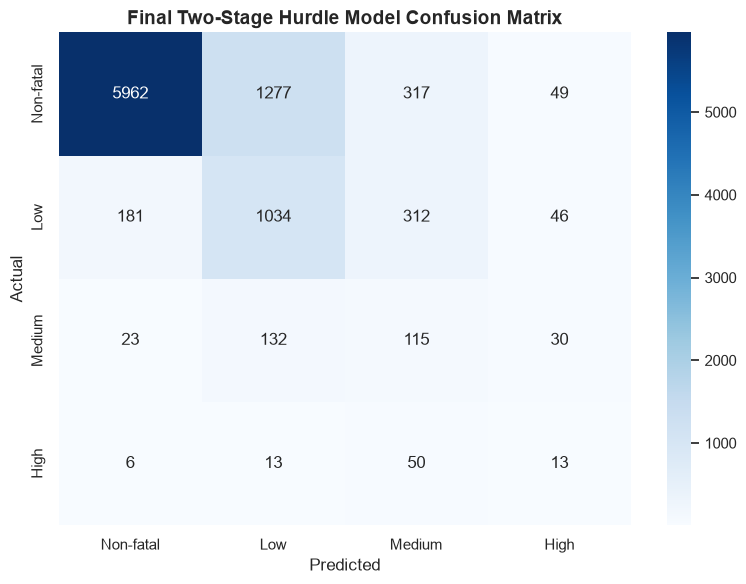

In [22]:
# 6.21 FINAL HURDLE MODEL EVALUATION

final_class_order = ["Non-fatal", "Low", "Medium", "High"]

combined_accuracy = accuracy_score(true_final_classes, final_pred_classes)
combined_precision = precision_score(true_final_classes, final_pred_classes, average="macro", zero_division=0)
combined_recall = recall_score(true_final_classes, final_pred_classes, average="macro", zero_division=0)
combined_f1 = f1_score(true_final_classes, final_pred_classes, average="macro", zero_division=0)

true_final_numeric = class_to_numeric(true_final_classes)
pred_final_numeric = class_to_numeric(final_pred_classes)
combined_numeric_metrics = regression_style_metrics(true_final_numeric, pred_final_numeric)

combined_summary = pd.DataFrame([{
    "Model System": "Final Two-Stage Hurdle Model",
    "Stage 1 Model": best_stage1_final_name,
    "Stage 2 Model": best_stage2_final_name,
    "Accuracy": combined_accuracy,
    "Macro Precision": combined_precision,
    "Macro Recall": combined_recall,
    "Macro F1": combined_f1,
    "MAE": combined_numeric_metrics["MAE"],
    "RMSE": combined_numeric_metrics["RMSE"],
    "RAE": combined_numeric_metrics["RAE"],
    "R2": combined_numeric_metrics["R2"]
}])

display(combined_summary)

print(classification_report(true_final_classes, final_pred_classes, zero_division=0))

cm = confusion_matrix(true_final_classes, final_pred_classes, labels=final_class_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=final_class_order,
    yticklabels=final_class_order
)

plt.title("Final Two-Stage Hurdle Model Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

The final Two-Stage Hurdle Model achieved 74.52% overall accuracy and a Macro F1-score of 42.68%, demonstrating good overall performance despite substantial class imbalance. The confusion matrix shows that the model identifies Non-fatal (F1 = 0.87) and Low severity (F1 = 0.51) events effectively, while performance on the minority Medium (F1 = 0.21) and High (F1 = 0.12) severity classes remains limited due to their low representation. Overall, the model is well-suited for operational fatality detection and provides a strong baseline for severity prediction, with future improvements focused on enhancing minority-class classification through additional data and imbalance-handling techniques.

## 6.22 Advanced Tabular Transformer Models (Optional)

FT-Transformer, TabTransformer, and SAINT are advanced deep learning models for tabular data.

They are included as advanced candidates after classical models.

In [23]:
# 6.22 ADVANCED TABULAR TRANSFORMERS

try:
    import torch
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False

try:
    from pytorch_tabular import TabularModel
    from pytorch_tabular.models import FTTransformerConfig, TabTransformerConfig
    from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig
    HAS_PYTORCH_TABULAR = True
except Exception:
    HAS_PYTORCH_TABULAR = False

if not HAS_TORCH or not HAS_PYTORCH_TABULAR:
    print("Advanced transformer models skipped.")
    print("Reason: PyTorch and/or pytorch-tabular is not installed.")
    print("This is acceptable because tree-based models remain the main professional benchmark.")
else:
    print("Advanced transformer libraries are available.")
    print("You may train FT-Transformer and TabTransformer here as experimental candidates.")
    print("SAINT usually requires a separate implementation and should be treated as optional.")

Advanced transformer models skipped.
Reason: PyTorch and/or pytorch-tabular is not installed.
This is acceptable because tree-based models remain the main professional benchmark.


## 6.23 Direct Regression Comparison

Direct regression is tested only as a comparison.

It is not the final modelling approach.

Regression tries to predict exact fatality counts, but exact counts are difficult because fatalities are zero-inflated, skewed, and rare-event driven.

In [24]:
# 6.23 DIRECT REGRESSION COMPARISON

regression_models = {
    "Dummy Regressor": DummyRegressor(strategy="median"),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

if HAS_XGBOOST:
    regression_models["XGBoost Regressor"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="count:poisson",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

regression_results = {}

for model_name, model in regression_models.items():
    print("\nTraining regression model:", model_name)

    pipe = make_pipeline(model)
    pipe.fit(X_train, y_reg_train)

    y_pred = pipe.predict(X_test)
    y_pred = np.clip(y_pred, 0, None)

    regression_results[model_name] = {
        "MAE": mean_absolute_error(y_reg_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_reg_test, y_pred)),
        "RAE": relative_absolute_error(y_reg_test, y_pred),
        "R2": r2_score(y_reg_test, y_pred)
    }

regression_results_df = pd.DataFrame(regression_results).T.sort_values("MAE")
display(regression_results_df)


Training regression model: Dummy Regressor

Training regression model: Random Forest Regressor

Training regression model: Gradient Boosting Regressor

Training regression model: XGBoost Regressor


,MAE,RMSE,RAE,R2
Dummy Regressor,0.4086,1.5054,0.6285,-0.0795
XGBoost Regressor,0.5342,1.3647,0.8219,0.1129
Gradient Boosting Regressor,0.7194,1.7568,1.1067,-0.4702
Random Forest Regressor,0.7481,2.0721,1.1509,-1.0452


Among the regression models, XGBoost Regressor performed best, achieving the lowest RMSE (1.3647), the only positive R² (0.1129), and outperforming the baseline. In contrast, Random Forest and Gradient Boosting did not improve upon the baseline, indicating that XGBoost is the most suitable regression model for predicting fatality counts.

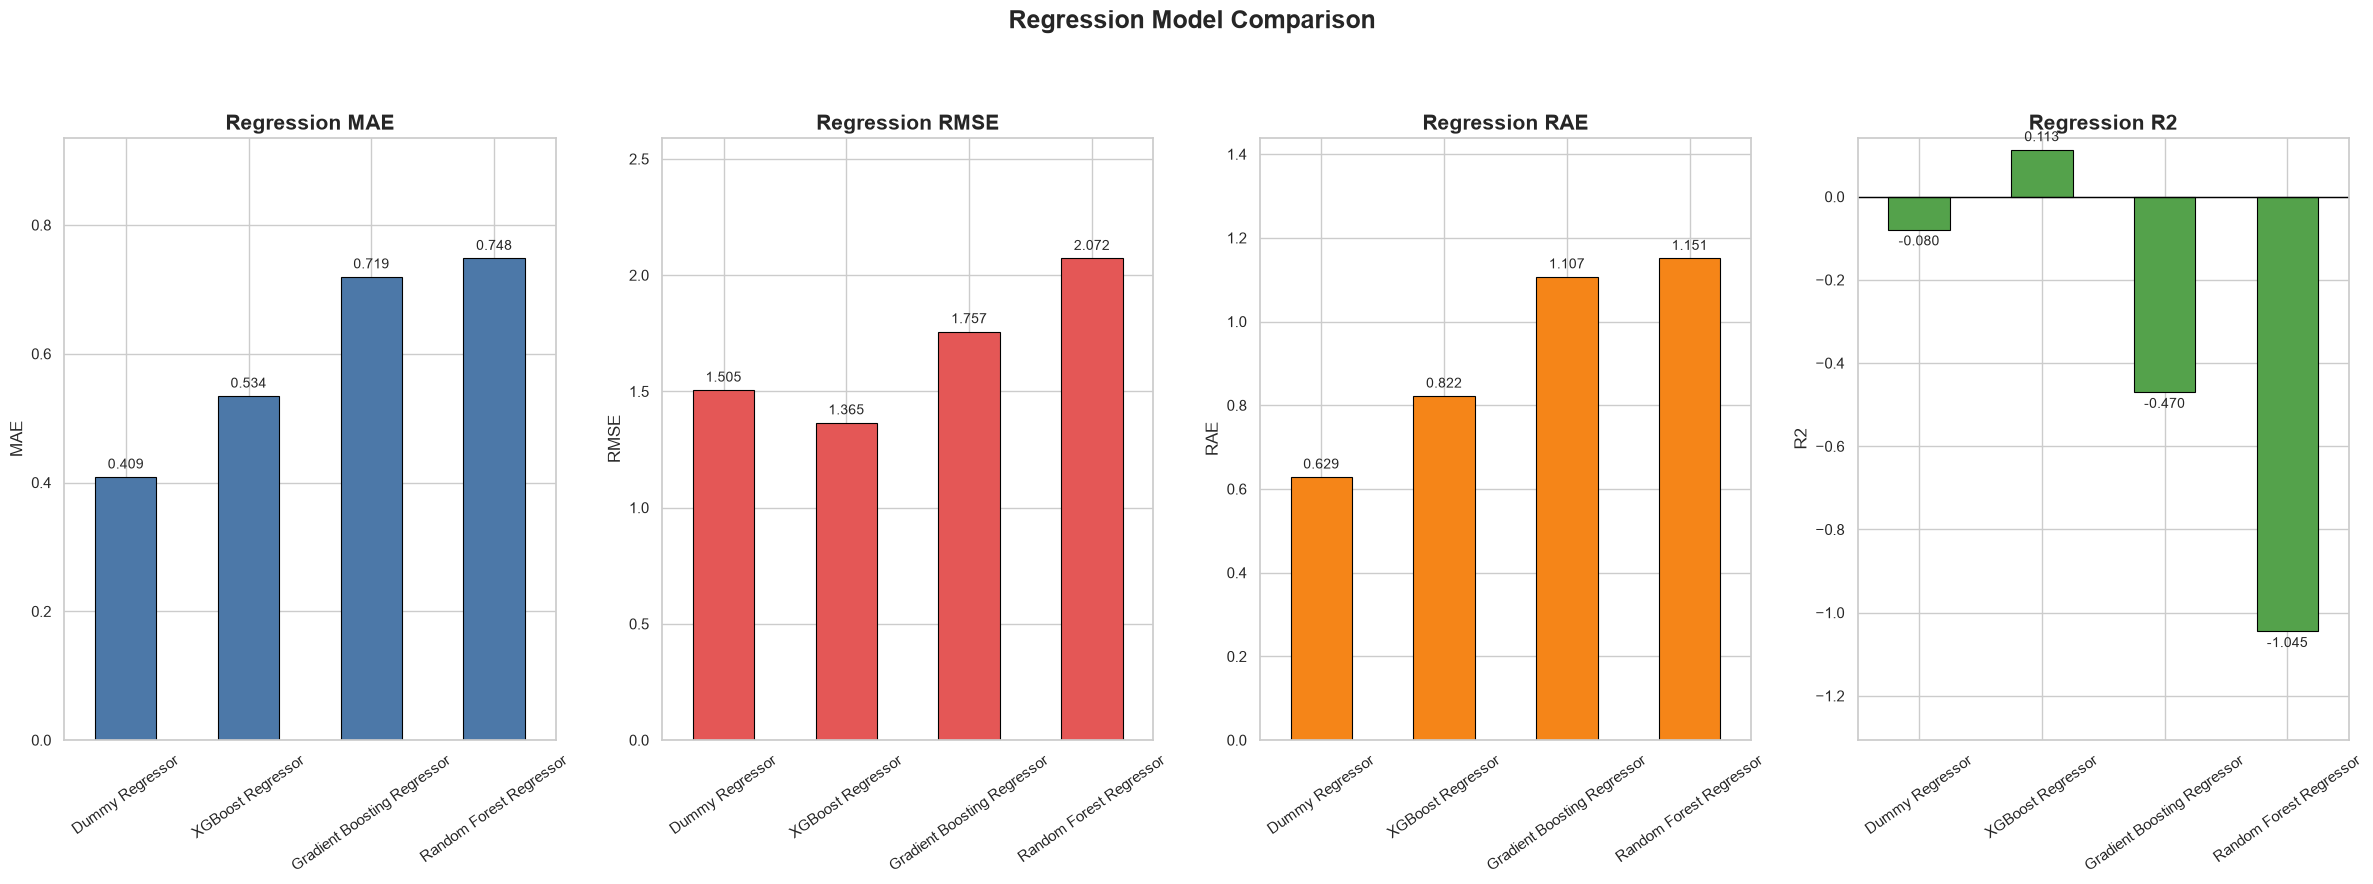

In [25]:
# 6.24 REGRESSION VISUALISATION

fig, axes = plt.subplots(1, 4, figsize=(24, 9))

metrics = [
    ("MAE", "#4C78A8", "Regression MAE"),
    ("RMSE", "#E45756", "Regression RMSE"),
    ("RAE", "#F58518", "Regression RAE"),
    ("R2", "#54A24B", "Regression R2")
]

for ax, (metric, color, title) in zip(axes, metrics):
    regression_results_df[metric].plot(
        kind="bar",
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=35)

    ymin = regression_results_df[metric].min()
    ymax = regression_results_df[metric].max()

    if metric == "R2":
        ax.axhline(0, color="black", linewidth=1)
        ax.set_ylim(ymin * 1.25 if ymin < 0 else 0, ymax * 1.25 if ymax > 0 else 0.1)
    else:
        ax.set_ylim(0, ymax * 1.25)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=10, padding=4)

plt.suptitle("Regression Model Comparison", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 6.25 Feature Importance

Feature importance explains which features the selected models rely on most.

This gives a first interpretability layer before SHAP.

,Feature,Importance
78,DISORDER_TYPE_Political violence,0.1522
77,DISORDER_TYPE_Demonstrations,0.1167
49,EVENT_TYPE_Protests,0.0957
70,SUB_EVENT_TYPE_Peaceful protest,0.0652
58,SUB_EVENT_TYPE_Attack,0.0476
90,LOG_PWD_DENSITY,0.0306
52,EVENT_TYPE_Violence against civilians,0.0267
82,YEAR,0.0267
92,LOG_PWD_G,0.0261
56,SUB_EVENT_TYPE_Armed clash,0.0254


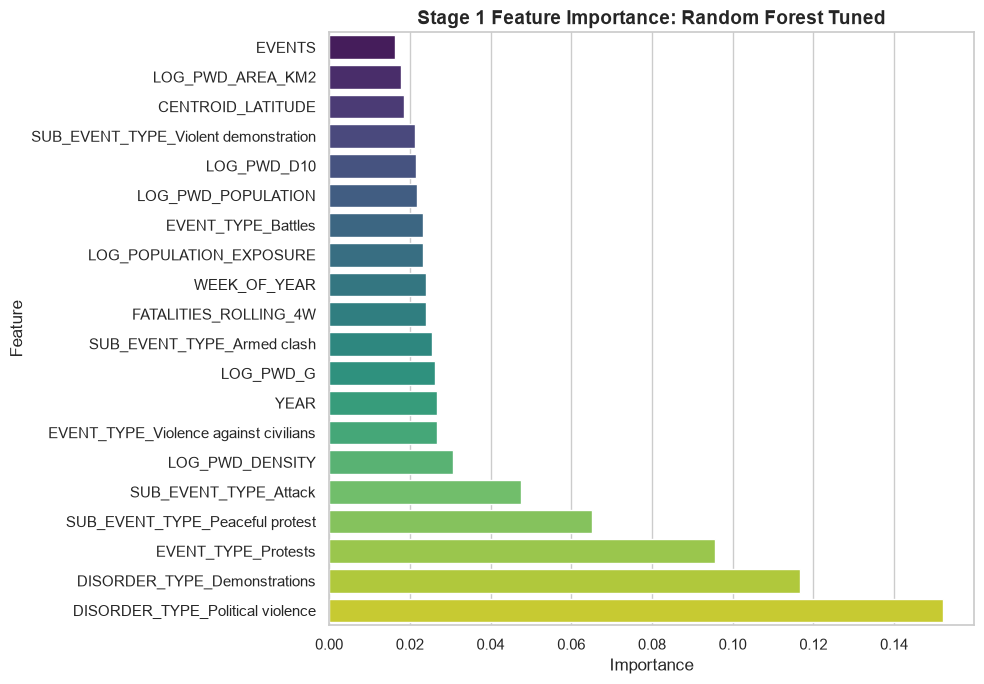

,Feature,Importance
71,YEAR,0.0780
79,LOG_PWD_DENSITY,0.0764
88,FATALITIES_ROLLING_4W,0.0740
81,LOG_PWD_G,0.0731
70,EVENTS,0.0684
77,LOG_POPULATION_EXPOSURE,0.0564
80,LOG_PWD_AREA_KM2,0.0527
82,LOG_PWD_D10,0.0507
78,LOG_PWD_POPULATION,0.0499
83,CENTROID_LATITUDE,0.0442


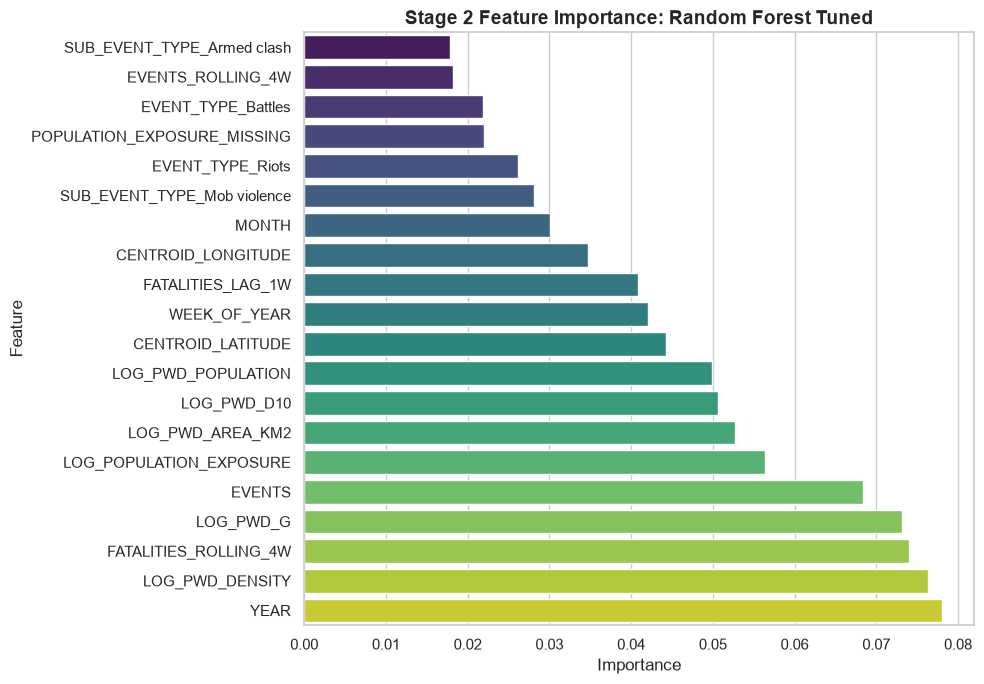

In [26]:
# 6.25 FEATURE IMPORTANCE

def get_feature_names_from_pipeline(pipeline):
    fitted_preprocessor = pipeline.named_steps["preprocessor"]
    cat_names = fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
    return list(cat_names) + numeric_features


def plot_feature_importance(pipeline, title, top_n=20):
    model = pipeline.named_steps["model"]

    if not hasattr(model, "feature_importances_"):
        print(title)
        print("This model does not support feature_importances_.")
        return None

    feature_names = get_feature_names_from_pipeline(pipeline)

    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": model.feature_importances_
        })
        .sort_values("Importance", ascending=False)
        .head(top_n)
    )

    display(importance_df)

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=importance_df.sort_values("Importance"),
        x="Importance",
        y="Feature",
        palette="viridis"
    )
    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return importance_df


stage1_importance_df = plot_feature_importance(
    best_stage1_final_model,
    f"Stage 1 Feature Importance: {best_stage1_final_name}"
)

stage2_importance_df = plot_feature_importance(
    best_stage2_final_model,
    f"Stage 2 Feature Importance: {best_stage2_final_name}"
)

## 6.26 SHAP Explainability

SHAP explains how the final models make predictions.

SHAP should be interpreted as model explanation, not causal proof.

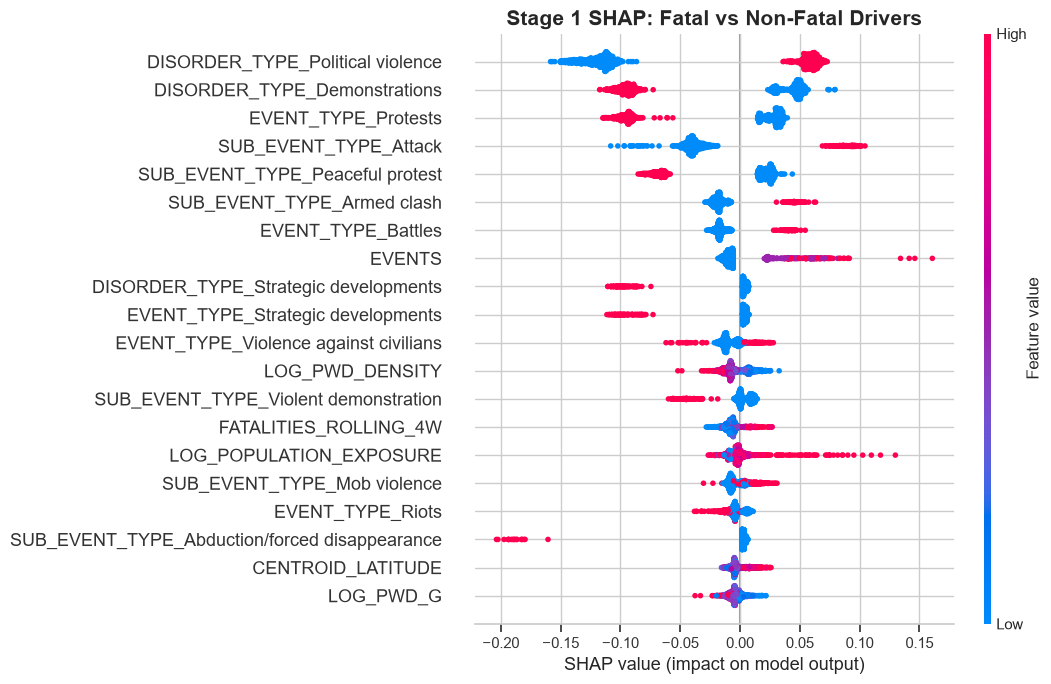

In [27]:
# 6.26 SHAP EXPLAINABILITY

if not HAS_SHAP:
    print("SHAP is not installed. Skipping SHAP section.")
else:
    def transform_for_shap(pipeline, X_data):
        fitted_preprocessor = pipeline.named_steps["preprocessor"]
        fitted_model = pipeline.named_steps["model"]

        X_transformed = fitted_preprocessor.transform(X_data)

        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()

        feature_names = get_feature_names_from_pipeline(pipeline)

        return X_transformed, fitted_model, feature_names

    shap_sample_size = min(1000, len(X_test))
    X_stage1_shap_raw = X_test.sample(shap_sample_size, random_state=RANDOM_STATE)

    X_stage1_shap, stage1_model_for_shap, stage1_feature_names = transform_for_shap(
        best_stage1_final_model,
        X_stage1_shap_raw
    )

    stage1_explainer = shap.TreeExplainer(stage1_model_for_shap)
    stage1_shap_values_raw = stage1_explainer.shap_values(X_stage1_shap)

    if isinstance(stage1_shap_values_raw, list):
        stage1_shap_values = stage1_shap_values_raw[1]
    else:
        stage1_array = np.array(stage1_shap_values_raw)
        if stage1_array.ndim == 3:
            stage1_shap_values = stage1_array[:, :, 1]
        else:
            stage1_shap_values = stage1_array

    shap.summary_plot(
        stage1_shap_values,
        X_stage1_shap,
        feature_names=stage1_feature_names,
        max_display=20,
        show=False,
        plot_size=(11, 7)
    )

    plt.title("Stage 1 SHAP: Fatal vs Non-Fatal Drivers", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

SHAP analysis shows that the model's predictions are primarily driven by disorder type, event type, sub-event type, historical event frequency, population exposure, and past fatalities. Features such as political violence, attacks, battles, and higher event counts increase the likelihood of predicting fatal incidents, while demonstrations and peaceful protests are associated with non-fatal outcomes. These results demonstrate that the model bases its decisions on meaningful conflict characteristics rather than arbitrary patterns, enhancing its interpretability and credibility for stakeholders.

## 6.27 Vulnerability Index

The final model predicts classes, not exact fatalities.

To rank counties, predicted classes are converted into severity scores:

- `Non-fatal` = 0
- `Low` = 1
- `Medium` = 4
- `High` = 8

These scores are aggregated by county to produce a vulnerability index.

In [28]:
# 6.27 COUNTY VULNERABILITY INDEX

predicted_severity_score = class_to_numeric(final_pred_classes)
actual_severity_score = class_to_numeric(true_final_classes)

county_test = df.loc[test_mask, "ADMIN1"].reset_index(drop=True)

vuln = pd.DataFrame({
    "COUNTY": county_test,
    "PREDICTED_CLASS": final_pred_classes,
    "ACTUAL_CLASS": true_final_classes,
    "PREDICTED_SEVERITY_SCORE": predicted_severity_score,
    "ACTUAL_SEVERITY_SCORE": actual_severity_score,
    "ACTUAL_FATALITIES": y_reg_test.reset_index(drop=True)
})

county_agg = (
    vuln.groupby("COUNTY")
    .agg(
        PREDICTED_TOTAL_SEVERITY=("PREDICTED_SEVERITY_SCORE", "sum"),
        ACTUAL_TOTAL_SEVERITY=("ACTUAL_SEVERITY_SCORE", "sum"),
        ACTUAL_TOTAL_FATALITIES=("ACTUAL_FATALITIES", "sum"),
        TEST_ROWS=("COUNTY", "size")
    )
    .sort_values("PREDICTED_TOTAL_SEVERITY", ascending=False)
    .reset_index()
)

county_agg["RANK"] = county_agg.index + 1

display(county_agg.head(15))

,COUNTY,PREDICTED_TOTAL_SEVERITY,ACTUAL_TOTAL_SEVERITY,ACTUAL_TOTAL_FATALITIES,TEST_ROWS,RANK
0,Mandera,635,241,256,235,1
1,Garissa,558,252,272,249,2
2,Samburu,533,149,154,217,3
3,Turkana,521,198,263,267,4
4,Lamu,428,195,298,175,5
5,Isiolo,420,123,142,208,6
6,Marsabit,344,106,114,139,7
7,Baringo,281,105,126,262,8
8,Wajir,245,46,49,75,9
9,Nairobi,209,268,289,865,10


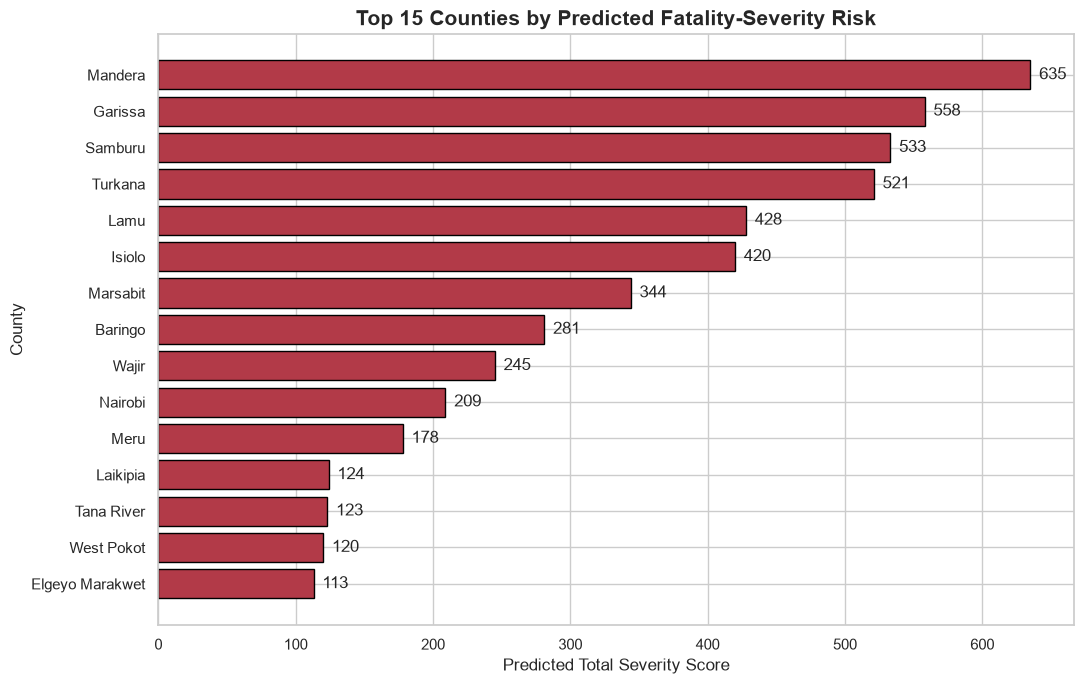

In [29]:
# 6.27.1 VULNERABILITY INDEX VISUAL

top_counties = county_agg.head(15).sort_values("PREDICTED_TOTAL_SEVERITY")

plt.figure(figsize=(11, 7))

plt.barh(
    top_counties["COUNTY"],
    top_counties["PREDICTED_TOTAL_SEVERITY"],
    color="#B23A48",
    edgecolor="black"
)

plt.title("Top 15 Counties by Predicted Fatality-Severity Risk", fontsize=15, fontweight="bold")
plt.xlabel("Predicted Total Severity Score")
plt.ylabel("County")

for index, value in enumerate(top_counties["PREDICTED_TOTAL_SEVERITY"]):
    plt.text(value + max(top_counties["PREDICTED_TOTAL_SEVERITY"]) * 0.01, index, round(value, 1), va="center")

plt.tight_layout()
plt.show()

## 6.28 Choropleth Map

It visualises predicted fatality-severity risk geographically.

This is important because conflict risk in Kenya is spatially patterned.

The choropleth should map:

- predicted total severity score
- actual fatalities
- county rank

In [30]:
!pip install geopandas

In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the shapefile / geojson
geo = gpd.read_file("your_map_file.geojson")   # or .shp

# Check column names
print(geo.columns)
print(df.columns)

# Merge your normal dataframe with the map dataframe
merged_geo = geo.merge(
    df,
    left_on="county",      # change to the county/region column in geo
    right_on="county",     # change to the matching column in df
    how="left"
)

# Plot the map
fig, ax = plt.subplots(figsize=(12, 8))

merged_geo.plot(
    column="value",        # change to the column you want to show on the map
    cmap="YlOrRd",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title("Map Visualization", fontsize=16)
ax.axis("off")

plt.show()

DataSourceError: your_map_file.geojson: No such file or directory

## 6.29 Master Model Comparison

This table combines:

- Stage 1 model results
- Stage 2 model results
- Final hurdle model results
- Regression comparison results

This is the final scoring and evaluation summary.

In [ ]:
# 6.29 MASTER MODEL COMPARISON

stage1_master = stage1_all_results.copy().reset_index().rename(columns={"index": "Model"})
stage1_master["Stage"] = "Stage 1: Fatal vs Non-Fatal"
stage1_master["Model Type"] = "Classification"
stage1_master["Primary Metric"] = "F1"

stage2_master = stage2_all_results.copy().reset_index().rename(columns={"index": "Model"})
stage2_master["Stage"] = "Stage 2: Severity"
stage2_master["Model Type"] = "Classification"
stage2_master["Primary Metric"] = "Macro F1"

final_master = combined_summary.copy().rename(columns={"Model System": "Model"})
final_master["Stage"] = "Final Hurdle System"
final_master["Model Type"] = "Two-Stage Hurdle"
final_master["Primary Metric"] = "Macro F1"

regression_master = regression_results_df.copy().reset_index().rename(columns={"index": "Model"})
regression_master["Stage"] = "Direct Regression Comparison"
regression_master["Model Type"] = "Regression Benchmark"
regression_master["Primary Metric"] = "MAE / RMSE / R2"

common_columns = [
    "Stage", "Model Type", "Model", "Primary Metric",
    "Accuracy", "Precision", "Recall", "F1",
    "Macro Precision", "Macro Recall", "Macro F1",
    "MAE", "RMSE", "RAE", "R2"
]

tables = [stage1_master, stage2_master, final_master, regression_master]

for i, table in enumerate(tables):
    for col in common_columns:
        if col not in table.columns:
            table[col] = np.nan
    tables[i] = table[common_columns]

master_model_comparison = pd.concat(tables, ignore_index=True)

display(master_model_comparison)

,Stage,Model Type,Model,Primary Metric,Accuracy,Precision,Recall,F1,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
0,Stage 1: Fatal vs Non-Fatal,Classification,Random Forest Tuned,F1,0.8062,0.5151,0.8926,0.6532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Stage 1: Fatal vs Non-Fatal,Classification,Random Forest,F1,0.7950,0.4993,0.9330,0.6505,NaN,NaN,NaN,0.2050,0.4528,0.6301,-0.2603
2,Stage 1: Fatal vs Non-Fatal,Classification,XGBoost,F1,0.8301,0.5700,0.6895,0.6241,NaN,NaN,NaN,0.1699,0.4122,0.5221,-0.0442
3,Stage 1: Fatal vs Non-Fatal,Classification,XGBoost Tuned,F1,0.8321,0.5756,0.6813,0.6240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Stage 1: Fatal vs Non-Fatal,Classification,Gradient Boosting Tuned,F1,0.8318,0.5759,0.6731,0.6208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Stage 1: Fatal vs Non-Fatal,Classification,Gradient Boosting,F1,0.8338,0.5821,0.6634,0.6201,NaN,NaN,NaN,0.1662,0.4077,0.5109,-0.0217
6,Stage 1: Fatal vs Non-Fatal,Classification,Dummy Baseline,F1,0.7955,0.0000,0.0000,0.0000,NaN,NaN,NaN,0.2045,0.4522,0.6285,-0.2571
7,Stage 2: Severity,Classification,Random Forest Tuned,Macro F1,0.6870,NaN,NaN,NaN,0.4208,0.4390,0.4232,NaN,NaN,NaN,NaN
8,Stage 2: Severity,Classification,Random Forest,Macro F1,0.6926,NaN,NaN,NaN,0.4086,0.4240,0.4122,1.1151,2.1365,0.9191,-0.5917
9,Stage 2: Severity,Classification,XGBoost Tuned,Macro F1,0.7662,NaN,NaN,NaN,0.4106,0.3810,0.3866,NaN,NaN,NaN,NaN


Overall Modeling Summary: The two-stage hurdle framework proved effective for predicting political violence outcomes. Tuned Random Forest was the best-performing classifier in both stages, achieving the highest F1-score (65.32%) for fatality detection and the highest Macro F1-score (42.32%) for severity classification. The final hurdle model attained 74.52% overall accuracy and 42.68% Macro F1, demonstrating strong performance despite significant class imbalance. Compared with direct regression approaches, the classification-based hurdle model provides more reliable and interpretable predictions for operational decision-making, while SHAP analysis confirms that predictions are driven by meaningful conflict characteristics such as disorder type, event type, attacks, historical fatalities, and population exposure. Overall, the proposed framework offers a robust, explainable, and practical solution for supporting early warning and resource allocation in political violence risk management.

## 6.30 Limitations

Important limitations:

- Political violence is affected by sudden shocks.
- ACLED reporting may vary by county and period.
- Severe fatality events are rare.
- Recent years have more events but lower average fatalities.
- The model learns historical patterns, not future political certainty.
- SHAP explains model behaviour, not causality.

Note:

**The model supports fatality-severity risk prioritisation. It does not replace expert judgement, field intelligence, or political context analysis.**

# Final Modelling Conclusions

- The **Two-Stage Hurdle Classification Model** was selected as the final modelling approach for predicting political violence outcomes.
- The modelling framework separates **fatality occurrence** from **fatality severity**, allowing each problem to be modelled independently for improved predictive performance.
- **Stage 1** predicts whether an event is **fatal or non-fatal**, while **Stage 2** classifies fatal events into **Low, Medium, or High** severity.
- The severity classes were redefined to three categories because the original highest fatality class was too rare to learn reliably.
- **Tuned Random Forest** was selected as the best-performing model in both stages, achieving the strongest balance between detection capability and overall predictive performance.
- **Macro F1-score** was adopted as the primary evaluation metric since it provides a fair assessment under class imbalance by considering performance across all classes equally.
- Direct regression models were evaluated as benchmark models but did not outperform the proposed two-stage classification framework.
- The final two-stage hurdle model achieved strong overall performance while remaining interpretable through **SHAP**, demonstrating that predictions are driven by meaningful conflict characteristics such as disorder type, event type, historical fatalities, and population exposure.
- The model is designed as a **decision-support and early warning system** for county-level political violence risk prioritisation, enabling proactive resource allocation and intervention planning rather than predicting exact fatality counts.